<a href="https://colab.research.google.com/github/muhyassin09/yasinnn/blob/main/medical-survival-analysis/analysis/heart-failure-survival-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HEART FAILURE CLINICAL RECORDS — SURVIVAL ANALYSIS

1. Phase A: Data Loading & Validation
2. Phase B: Baseline Characteristics (Table 1)
3. Phase C: Kaplan-Meier Survival Analysis (stratified by Hypertension)
4. Phase D: Multivariable Cox Proportional Hazards Model
5. Phase E: Proportional Hazards Assumption Check (Schoenfeld Residuals)

## Phase A: DATA PREPROCESSING

Environment Setup

In [2]:
!pip install -q tableone lifelines ucimlrepo

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.6 MB/s eta 0:00:00


In [3]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tableone import TableOne
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, proportional_hazard_test
from lifelines.plotting import add_at_risk_counts

INPUT DATA

In [4]:
heart_failure_data = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [5]:
heart_failure_data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
heart_failure_data = heart_failure_data.apply(pd.to_numeric)

In [7]:
print(heart_failure_data.isnull())

       age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    False    False                     False     False              False   
1    False    False                     False     False              False   
2    False    False                     False     False              False   
3    False    False                     False     False              False   
4    False    False                     False     False              False   
..     ...      ...                       ...       ...                ...   
294  False    False                     False     False              False   
295  False    False                     False     False              False   
296  False    False                     False     False              False   
297  False    False                     False     False              False   
298  False    False                     False     False              False   

     high_blood_pressure  platelets  serum_creatinine  serum_so

In [8]:
print(heart_failure_data.describe())

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

In [9]:
n_deaths = heart_failure_data["DEATH_EVENT"].sum()
n_total = len(heart_failure_data)

print(f"Loaded cohort: N = {n_total} rows | Deaths = {n_deaths} ({100 * n_deaths / n_total:.1f}%)")

Loaded cohort: N = 299 rows | Deaths = 96 (32.1%)


In [10]:
heart_failure_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


## Phase B: BASELINE CHARACTERISTICS

####Variable Typing & Labeling
*Changing the biner 0/1 column into categorical labelled as 'No'/'Yes'*

In [16]:
categorical_columns = [
    "anaemia", "diabetes", "high_blood_pressure",
    "sex", "smoking", "DEATH_EVENT"
]

In [17]:
label_maps = {
    "anaemia":             {0: "No", 1: "Yes"},
    "diabetes":            {0: "No", 1: "Yes"},
    "high_blood_pressure": {0: "No", 1: "Yes"},
    "smoking":             {0: "No", 1: "Yes"},
    "sex":                 {0: "Female", 1: "Male"},
    "DEATH_EVENT":         {0: "Survived", 1: "Deceased"},
}

In [22]:
groupby_column = "DEATH_EVENT"

In [23]:
heart_failure_tbl1 = heart_failure_data.copy()
for col, mapping in label_maps.items():
    if col == groupby_column:
        heart_failure_tbl1[col] = heart_failure_tbl1[col].map(mapping).astype("object")
    else:
        heart_failure_tbl1[col] = heart_failure_tbl1[col].map(mapping).astype("category")

In [24]:
display_labels = {
    "age":                      "Age (years)",
    "anaemia":                  "Anaemia",
    "creatinine_phosphokinase": "Creatine Phosphokinase (mcg/L)",
    "diabetes":                 "Diabetes Mellitus",
    "ejection_fraction":        "Ejection Fraction (%)",
    "high_blood_pressure":      "Hypertension",
    "platelets":                "Platelets (kiloplatelets/mL)",
    "serum_creatinine":         "Serum Creatinine (mg/dL)",
    "serum_sodium":             "Serum Sodium (mEq/L)",
    "sex":                      "Sex",
    "smoking":                  "Current Smoker",
    "time":                     "Follow-up Time (days)",
}

#####Baseline Characteristics

*Comparing patient's characteristics based on their baseline between two outcome (Survived vs Deceased)*

In [25]:
continuous_columns = [
    "age", "creatinine_phosphokinase", "ejection_fraction",
    "platelets", "serum_creatinine", "serum_sodium", "time"
]

nonnormal_override = [
    "creatinine_phosphokinase", "platelets", "serum_creatinine", "time"
]

In [27]:
table1 = TableOne(
    data=heart_failure_tbl1,
    columns=continuous_columns + categorical_columns,
    categorical=categorical_columns,
    groupby=groupby_column,
    nonnormal=nonnormal_override,
    pval=True,
    pval_test_name=True,
    htest_name=True,
    overall=True,
    rename=display_labels,
    label_suffix=True,
)

In [28]:
print(table1.tabulate(tablefmt="fancy_grid"))

╒════════════════════════════════════════════════╤══════════╤═══════════╤══════════════════════════════╤══════════════════════════════╤══════════════════════════════╤═══════════╤════════════════╕
│                                                │          │ Missing   │ Overall                      │ Deceased                     │ Survived                     │ P-Value   │ Test           │
╞════════════════════════════════════════════════╪══════════╪═══════════╪══════════════════════════════╪══════════════════════════════╪══════════════════════════════╪═══════════╪════════════════╡
│ n                                              │          │           │ 299                          │ 96                           │ 203                          │           │                │
├────────────────────────────────────────────────┼──────────┼───────────┼──────────────────────────────┼──────────────────────────────┼──────────────────────────────┼───────────┼────────────────┤
│ Age (years), mean 

In [90]:
table1.to_csv("table1_baseline_characteristics.csv")

## Phase C: KAPLAN-MEIER SURVIVAL ANALYSIS

#####Kaplan Meier Estimation ~Stratified by Hypertension

*The Kaplan-Meier method calculates survival odds step-by-step, every time an event occurs. At each step, it only counts the patients who are still actively being tracked, meaning it easily handles people who leave the study early or are still alive when it ends.*

In [29]:
hypertension_group = heart_failure_data[heart_failure_data["high_blood_pressure"] == 1]
no_hypertension_group = heart_failure_data[heart_failure_data["high_blood_pressure"] == 0]

In [30]:
kmf_hypertension = KaplanMeierFitter(label="Hypertension: Yes")
kmf_no_hypertension = KaplanMeierFitter(label="Hypertension: No")

In [31]:
kmf_hypertension.fit(hypertension_group["time"], event_observed=hypertension_group["DEATH_EVENT"])
kmf_no_hypertension.fit(no_hypertension_group["time"], event_observed=no_hypertension_group["DEATH_EVENT"])

<lifelines.KaplanMeierFitter:"Hypertension: No", fitted with 194 total observations, 137 right-censored observations>

LOG-RANK TEST

*The log-rank test checks if two groups have truly different survival rates over the whole study, rather than just looking at a single moment. A small p-value proves that the two groups (like people with and without high blood pressure) have noticeably different survival times.*

In [32]:
logrank_result = logrank_test(
    durations_A=hypertension_group["time"],
    durations_B=no_hypertension_group["time"],
    event_observed_A=hypertension_group["DEATH_EVENT"],
    event_observed_B=no_hypertension_group["DEATH_EVENT"],
)

In [42]:
logrank_p_value = logrank_result.p_value

print(f"\nLog-rank test p-value (Hypertension vs. No Hypertension): {logrank_p_value:.4f}")


Log-rank test p-value (Hypertension vs. No Hypertension): 0.0358


There is a clear and meaningful difference in survival rates between the ones with Hypertension vs No Hypertension shown by 0,0358 < 0,05

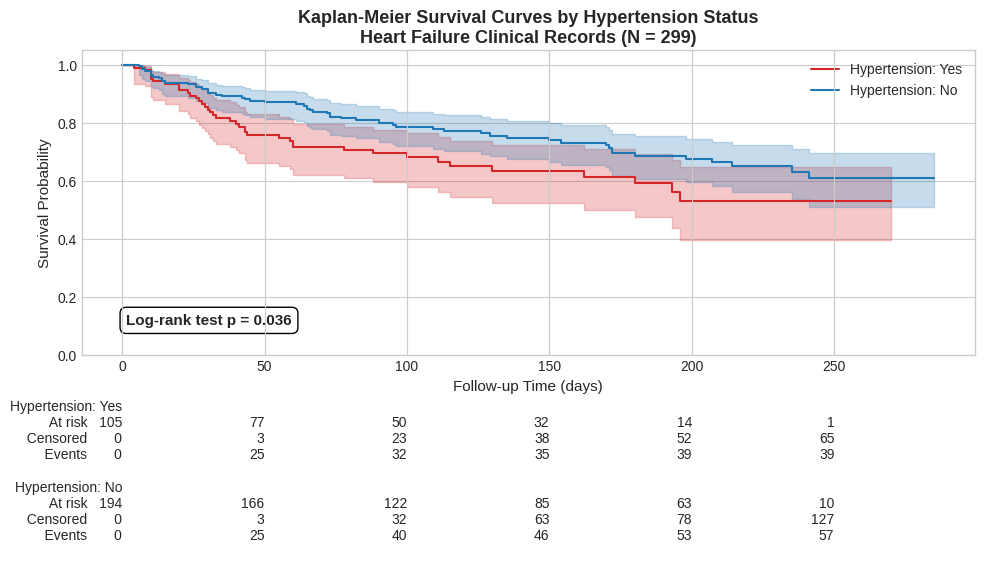

In [57]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

kmf_hypertension.plot_survival_function(ax=ax, ci_show=True, color="#D62728")
kmf_no_hypertension.plot_survival_function(ax=ax, ci_show=True, color="#1F77B4")

ax.text(
    0.05, 0.10,
    f"Log-rank test p = {logrank_p_value:.3f}",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.4")
)

ax.set_title(
    "Kaplan-Meier Survival Curves by Hypertension Status\nHeart Failure Clinical Records (N = 299)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Follow-up Time (days)", fontsize=11)
ax.set_ylabel("Survival Probability", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(title="", loc="upper right", fontsize=10)

add_at_risk_counts(kmf_hypertension, kmf_no_hypertension, ax=ax)

plt.tight_layout()
plt.savefig("km_curve_hypertension.png", dpi=300, bbox_inches="tight")
plt.show()

If more than half of the patients are still alive at the end of the study, the survival curve never drops to 50%. In this case, the software returns infinity (np.inf) instead of "missing data" (NaN). Always check for this using np.isinf(), not pd.isna().

In [58]:
median_survival_hypertension = kmf_hypertension.median_survival_time_
median_survival_no_hypertension = kmf_no_hypertension.median_survival_time_

In [61]:
print("Median Survival Time Summary ")
print(f"Hypertension: Yes -> "
      f"{'Not reached' if np.isinf(median_survival_hypertension) else f'{median_survival_hypertension:.0f} days'}")
print(f"Hypertension: No  -> "
      f"{'Not reached' if np.isinf(median_survival_no_hypertension) else f'{median_survival_no_hypertension:.0f} days'}")

Median Survival Time Summary 
Hypertension: Yes -> Not reached
Hypertension: No  -> Not reached


##Phase D: MULTIVARIABLE COX PROPORTIONAL HAZARDS MODEL

The Cox Proportional Hazards model estimates how much each factor changes a patient's IMMEDIATE RISK of dying at any given moment compared to a baseline patient, while keeping all other factors in the model constant.

In [62]:
heart_failure_data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


 The variables (age, high_blood_pressure, smoking, serum_creatinine)
 were chosen beforehand based on medical reasoning, not by letting a computer
 pick them from the data. Here is why each one matters:
   - age: The strongest natural risk factor for heart failure death.
   - high_blood_pressure: Causes long-term stress and damaging changes
     to the heart structure; this is our main focus.
   - smoking: A major heart health risk factor that a patient can change.
   - serum_creatinine: Tracks kidney health; poor kidney function is deeply
     linked to heart failure (eg. "*cardiorenal syndrome*").

In [63]:
cox_model_data = heart_failure_data[[
    "time", "DEATH_EVENT", "age", "high_blood_pressure", "smoking", "serum_creatinine"
]].copy()

In [65]:
cox_ph_model = CoxPHFitter()
cox_ph_model.fit(
    df=cox_model_data,
    duration_col="time",
    event_col="DEATH_EVENT",
)

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>

In [66]:
summary_table = cox_ph_model.summary.copy()

In [67]:
hr_table = pd.DataFrame({
    "Characteristic": summary_table.index,
    "HR": summary_table["exp(coef)"].round(2),
    "95% CI Lower": summary_table["exp(coef) lower 95%"].round(2),
    "95% CI Upper": summary_table["exp(coef) upper 95%"].round(2),
    "p-value": summary_table["p"].apply(
        lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
    )
})

In [68]:
hr_table["95% CI"] = (
    hr_table["95% CI Lower"].astype(str) + " – " + hr_table["95% CI Upper"].astype(str)
)

hr_table = hr_table[["Characteristic", "HR", "95% CI", "p-value"]]

In [70]:
characteristic_labels = {
    "age":                 "Age (per 1-year increase)",
    "high_blood_pressure": "Hypertension (Yes vs. No)",
    "smoking":             "Current Smoker (Yes vs. No)",
    "serum_creatinine":    "Serum Creatinine (per 1 mg/dL increase)",
}

hr_table["Characteristic"] = hr_table["Characteristic"].map(characteristic_labels)

In [73]:
print(hr_table.to_string(index=False))

                         Characteristic   HR      95% CI p-value
              Age (per 1-year increase) 1.04 1.03 – 1.06  <0.001
              Hypertension (Yes vs. No) 1.47 0.97 – 2.23   0.067
            Current Smoker (Yes vs. No) 1.15 0.74 – 1.77   0.540
Serum Creatinine (per 1 mg/dL increase) 1.33 1.19 – 1.49  <0.001


Concordance Index

*The probability that the model correctly ranks any two random patients by their risk. A score of 0.5 means the model is just guessing at random, while a perfect 1.0 means it flawlessly identifies who is at higher risk every single time.*

In [83]:
c_index = cox_ph_model.concordance_index_
print(f"\nC-Index: {c_index:.3f}")


C-Index: 0.675


Log-likelihood Ratio test

*This test checks whether all four factors working TOGETHER actually make the model better at predicting survival compared to a baseline model that uses no factors at all.*

In [84]:
p_val = cox_ph_model.log_likelihood_ratio_test().p_value
print(f"Model P-Value: {p_val:.4f}")

Model P-Value: 0.0000


In [86]:
hr_table.to_csv("cox_ph_hazard_ratios.csv", index=False)

## Phase F: PROPORTIONAL HAZARDS ASSUMPTION CHECK

Schoenfeld Residual test

*Checks if the risk factor's impact stays constant over time or if it changes as the study goes on.*

In [87]:
print("\n--- PH Assumption Check ---")
test_results = proportional_hazard_test(cox_ph_model, cox_model_data, time_transform="rank")
print(test_results.summary)


--- PH Assumption Check ---
                     test_statistic         p  -log2(p)
age                        0.292055  0.588906  0.763890
high_blood_pressure        0.534364  0.464778  1.105386
serum_creatinine           0.249275  0.617586  0.695288
smoking                    0.296394  0.586152  0.770653
